# 🧠 Mental Health Classification — Custom Deep Learning

**Dataset:** Teen Mental Health Dataset (Depression / No Depression)

### Fitur yang Diimplementasikan:
| # | Fitur | Detail |
|---|-------|--------|
| 1 | **TensorFlow Functional API** | Multi-input residual network |
| 2 | **Custom Layer** | `AttentionGating` + `ResidualBlock` |
| 3 | **Custom Loss Function** | `FocalLoss` untuk imbalanced data |
| 4 | **Custom Callback** | `EarlyStoppingWithRestore` + `LRWarmupCosineDecay` |
| 5 | **Custom Training Loop** | `tf.GradientTape` penuh (Side Quest) |
| 6 | **Model Export** | `.keras` format (production-ready) |
| 7 | **Inference Pipeline** | Preprocessing + predict end-to-end |

## 1. Setup & Install Dependencies

In [1]:
import os
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import Callback

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from imblearn.combine import SMOTETomek

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU Available       : {tf.config.list_physical_devices("GPU")}')

TensorFlow version : 2.20.0
GPU Available       : []


## 2. Load Dataset

In [2]:
# Upload kaggle.json lalu download dataset
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d algozee/teenager-menthal-healy/
!unzip -qq teenager-menthal-healy.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/algozee/teenager-menthal-healy/versions/
License(s): apache-2.0
100% 15.8k/15.8k [00:00<00:00, 39.8MB/s]



In [3]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')
print(f'Shape  : {df.shape}')
print(f'Kolom  : {df.columns.tolist()}')
df.head()

Shape  : (1200, 13)
Kolom  : ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## 3. Exploratory Data Analysis (EDA)

In [4]:
print('=== Info Dataset ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Duplikasi ===')
print(f'{df.duplicated().sum()} baris duplikat')
print('\n=== Distribusi Label ===')
print(df['depression_label'].value_counts())

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory 

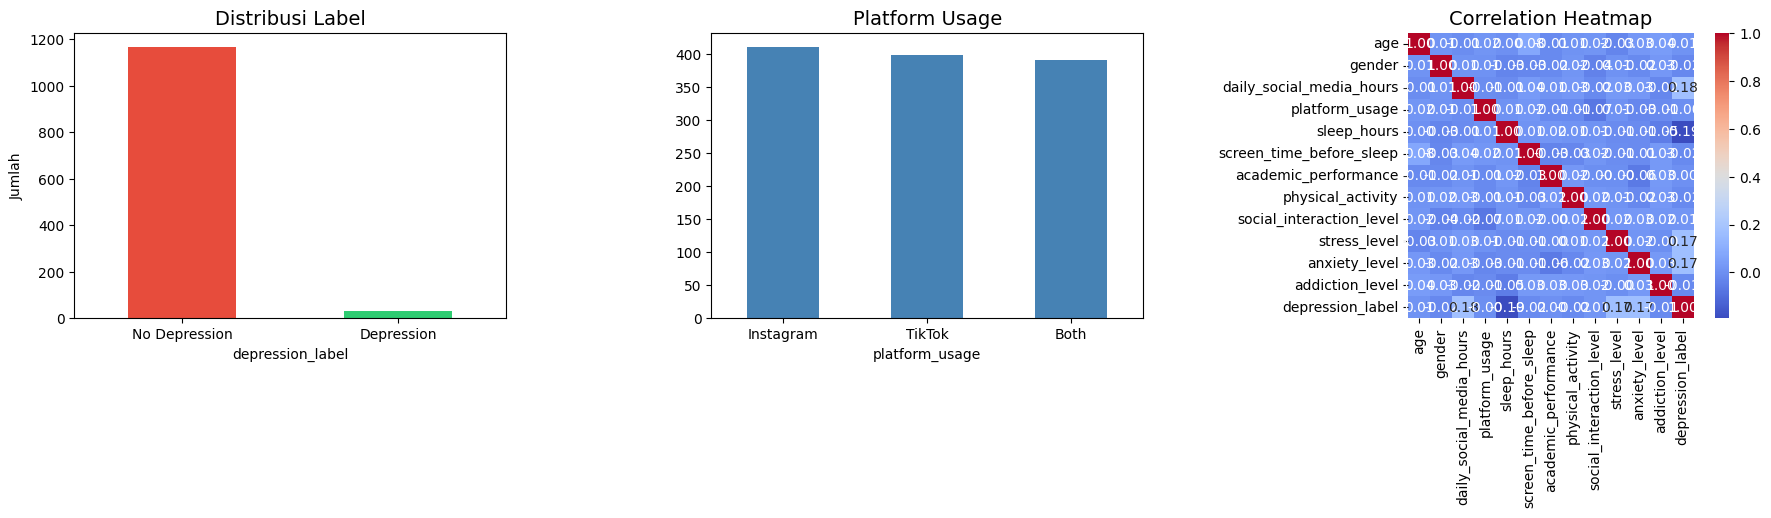

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribusi label
df['depression_label'].value_counts().rename({1: 'Depression', 0: 'No Depression'}).plot.bar(
    ax=axes[0], color=['#e74c3c', '#2ecc71'], rot=0
)
axes[0].set_title('Distribusi Label', fontsize=14)
axes[0].set_ylabel('Jumlah')

# Platform usage
df['platform_usage'].value_counts().plot.bar(ax=axes[1], color='steelblue', rot=0)
axes[1].set_title('Platform Usage', fontsize=14)

# Heatmap korelasi
df_num = df.copy()
df_num['gender'] = df_num['gender'].map({'male': 1, 'female': 0})
df_num['social_interaction_level'] = df_num['social_interaction_level'].map({'low': 0, 'medium': 1, 'high': 2})
df_num['platform_usage'] = df_num['platform_usage'].map({'Instagram': 0, 'TikTok': 1, 'Both': 2})
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], square=True)
axes[2].set_title('Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

## 4. Preprocessing & Feature Engineering

In [6]:
# Encoding kategorikal
df_proc = df.copy()
df_proc['gender'] = df_proc['gender'].map({'male': 1, 'female': 0})
df_proc['social_interaction_level'] = df_proc['social_interaction_level'].map({'low': 0, 'medium': 1, 'high': 2})
df_proc['platform_usage'] = df_proc['platform_usage'].map({'Instagram': 0, 'TikTok': 1, 'Both': 2})

# Menggunakan daily_social_media_hours dan sleep_hours
df_proc['screen_sleep_ratio']  = df_proc['daily_social_media_hours'] / (df_proc['sleep_hours'] + 1e-6)

# Social engagement tetap aman selama mapping di atas sukses
df_proc['social_engagement']   = df_proc['social_interaction_level'] * df_proc['platform_usage']

# Menggunakan anxiety_level dan stress_level
df_proc['mental_load_index']   = (df_proc['anxiety_level'] + df_proc['stress_level']) / 2

TARGET   = 'depression_label'
FEATURES = [c for c in df_proc.columns if c != TARGET]

X = df_proc[FEATURES].values.astype(np.float32)
y = df_proc[TARGET].values.astype(np.float32)

print(f'Total fitur : {X.shape[1]}')
print(f'Fitur       : {FEATURES}')

Total fitur : 15
Fitur       : ['age', 'gender', 'daily_social_media_hours', 'platform_usage', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'screen_sleep_ratio', 'social_engagement', 'mental_load_index']


In [7]:
# Train / Val / Test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train_raw, X_val, y_train_raw, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=SEED, stratify=y_temp
)

# SMOTETomek hanya pada training set
smote = SMOTETomek(random_state=SEED)
X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)

# StandardScaler fit pada training set saja
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_res).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

y_train = y_train_res.astype(np.float32)

print(f'Train  : {X_train.shape[0]} sampel')
print(f'Val    : {X_val.shape[0]} sampel')
print(f'Test   : {X_test.shape[0]} sampel')
print(f'\nLabel train : {np.unique(y_train, return_counts=True)}')

Train  : 1690 sampel
Val    : 153 sampel
Test   : 180 sampel

Label train : (array([0., 1.], dtype=float32), array([845, 845]))


## 5. Komponen Custom Deep Learning

### 5.1 Custom Layers

In [8]:
# Custom Layer 1: Residual Block
class ResidualBlock(layers.Layer):
    """Dense Residual Block dengan BatchNorm + Dropout."""

    def __init__(self, units: int, dropout_rate: float = 0.3, **kwargs):
        super().__init__(**kwargs)
        self.units        = units
        self.dropout_rate = dropout_rate

        self.dense1  = layers.Dense(units, use_bias=False)
        self.bn1     = layers.BatchNormalization()
        self.act1    = layers.Activation('swish')
        self.drop1   = layers.Dropout(dropout_rate)

        self.dense2  = layers.Dense(units, use_bias=False)
        self.bn2     = layers.BatchNormalization()
        self.act2    = layers.Activation('swish')

        # Projection shortcut jika dimensi berbeda
        self.proj    = None

    def build(self, input_shape):
        if input_shape[-1] != self.units:
            self.proj = layers.Dense(self.units, use_bias=False)
        super().build(input_shape)

    def call(self, x, training=False):
        shortcut = self.proj(x) if self.proj else x
        x = self.dense1(x)
        x = self.bn1(x, training=training)
        x = self.act1(x)
        x = self.drop1(x, training=training)
        x = self.dense2(x)
        x = self.bn2(x, training=training)
        x = self.act2(x + shortcut)   # residual connection
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units, 'dropout_rate': self.dropout_rate})
        return cfg

# Custom Layer 2: Attention Gating
class AttentionGating(layers.Layer):
    """Feature-wise attention: belajar bobot setiap fitur input."""

    def __init__(self, units: int, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W     = layers.Dense(units, activation='relu', use_bias=False)
        self.V     = layers.Dense(units, activation='sigmoid', use_bias=False)

    def call(self, x, training=False):
        score = self.W(x)
        gate  = self.V(score)
        return x * gate   # element-wise gating

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.units})
        return cfg


print('✅ Custom Layers terdefinisi: ResidualBlock, AttentionGating')

✅ Custom Layers terdefinisi: ResidualBlock, AttentionGating


### 5.2 Custom Loss Function

In [9]:
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss untuk dataset imbalanced.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    - alpha : bobot kelas positif (depression)
    - gamma : focusing parameter (down-weights easy examples)
    """

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0,
                 label_smoothing: float = 0.05, **kwargs):
        super().__init__(**kwargs)
        self.alpha           = alpha
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        # Label smoothing
        y_true_smooth = y_true * (1 - self.label_smoothing) + 0.5 * self.label_smoothing

        # Clip untuk numerik stabil
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        # Binary cross entropy per-sample
        bce = -(
            y_true_smooth * tf.math.log(y_pred) +
            (1 - y_true_smooth) * tf.math.log(1 - y_pred)
        )

        # Focal weight
        p_t  = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = tf.pow(1 - p_t, self.gamma)

        # Alpha weighting
        alpha_t = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)

        loss = alpha_t * focal_weight * bce
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            'alpha': self.alpha,
            'gamma': self.gamma,
            'label_smoothing': self.label_smoothing
        })
        return cfg


print('✅ Custom Loss terdefinisi: FocalLoss(alpha=0.25, gamma=2.0)')

✅ Custom Loss terdefinisi: FocalLoss(alpha=0.25, gamma=2.0)


### 5.3 Custom Callbacks

In [10]:
# Custom Callback 1: Early Stopping with Best Weight Restore
class EarlyStoppingWithRestore(Callback):
    """
    Early stopping yang memonitor val_accuracy.
    Otomatis restore bobot terbaik saat training selesai.
    """

    def __init__(self, patience: int = 20, min_delta: float = 0.001,
                 monitor: str = 'val_accuracy'):
        super().__init__()
        self.patience  = patience
        self.min_delta = min_delta
        self.monitor   = monitor

    def on_train_begin(self, logs=None):
        self.best_val    = -np.inf
        self.wait        = 0
        self.best_weights = None
        self.stopped_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor, -np.inf)
        if current > self.best_val + self.min_delta:
            self.best_val     = current
            self.wait         = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                print(f'\n[EarlyStop] Epoch {epoch+1}: berhenti. '
                      f'Best {self.monitor}={self.best_val:.4f}')

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print('[EarlyStop] Best weights telah di-restore.')

# Custom Callback 2: Warmup + Cosine Decay LR Schedule
class LRWarmupCosineDecay(Callback):
    """
    Learning rate schedule:
    - Linear warmup selama `warmup_epochs` epoch
    - Cosine decay setelahnya
    """

    def __init__(self, lr_start: float, lr_max: float, lr_min: float,
                 warmup_epochs: int, total_epochs: int):
        super().__init__()
        self.lr_start      = lr_start
        self.lr_max        = lr_max
        self.lr_min        = lr_min
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.lr_history    = []

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.lr_start + (self.lr_max - self.lr_start) * (epoch / max(self.warmup_epochs - 1, 1))
        else:
            progress = (epoch - self.warmup_epochs) / max(self.total_epochs - self.warmup_epochs, 1)
            lr = self.lr_min + 0.5 * (self.lr_max - self.lr_min) * (1 + math.cos(math.pi * progress))

        tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
        self.lr_history.append(lr)

# Custom Callback 3: Metrics Logger
class MetricsLogger(Callback):
    """Menyimpan history metrik untuk visualisasi."""

    def on_train_begin(self, logs=None):
        self.history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': [], 'lr': []}

    def on_epoch_end(self, epoch, logs=None):
        for key in ['loss', 'val_loss', 'accuracy', 'val_accuracy']:
            self.history[key].append(logs.get(key, 0))
        self.history['lr'].append(float(tf.keras.backend.get_value(self.model.optimizer.learning_rate)))


print('✅ Custom Callbacks terdefinisi: EarlyStoppingWithRestore, LRWarmupCosineDecay, MetricsLogger')

✅ Custom Callbacks terdefinisi: EarlyStoppingWithRestore, LRWarmupCosineDecay, MetricsLogger


## 6. Arsitektur Model (TensorFlow Functional API)

In [11]:
def build_mental_health_model(input_dim: int, name: str = 'MentalHealthNet') -> Model:
    """
    Arsitektur: Functional API dengan
    - AttentionGating layer (feature weighting)
    - 3x ResidualBlock
    - Global skip connection
    - Sigmoid output (binary classification)
    """
    inputs = keras.Input(shape=(input_dim,), name='features')

    # Attention gating
    x = AttentionGating(units=input_dim, name='attention_gate')(inputs)

    # Block 1
    x = ResidualBlock(units=128, dropout_rate=0.3, name='res_block_1')(x)

    # Block 2
    x = ResidualBlock(units=64, dropout_rate=0.3, name='res_block_2')(x)

    # Block 3
    x = ResidualBlock(units=32, dropout_rate=0.25, name='res_block_3')(x)

    # Bottleneck
    x = layers.Dense(16, activation='swish', name='bottleneck')(x)
    x = layers.Dropout(0.2, name='final_dropout')(x)

    # Output
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name=name)
    return model


INPUT_DIM = X_train.shape[1]
model = build_mental_health_model(INPUT_DIM)
model.summary()

# Visualisasikan arsitektur
try:
    keras.utils.plot_model(model, show_shapes=True, show_layer_names=True,
                           to_file='model_architecture.png', dpi=96)
    from IPython.display import Image
    Image('model_architecture.png')
except Exception:
    pass

Model: "MentalHealthNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_gate                  │ (None, 15)             │           450 │
│ (AttentionGating)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_1 (ResidualBlock)     │ (None, 128)            │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_2 (ResidualBlock)     │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_3 (ResidualBlock)     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_dropout (Dropout)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,611 (189.89 KB)

 Trainable params: 47,715 (186.39 KB)

 Non-trainable params: 896 (3.50 KB)

## 7. Custom Training Loop dengan `tf.GradientTape` *(Side Quest)*

In [12]:
# Hyperparameters
TOTAL_EPOCHS  = 150
WARMUP_EPOCHS = 10
BATCH_SIZE    = 64
LR_MAX        = 5e-4
LR_MIN        = 1e-6
LR_START      = 1e-5

# Loss & Optimizer
focal_loss = FocalLoss(alpha=0.25, gamma=2.0, label_smoothing=0.05)
optimizer  = keras.optimizers.AdamW(learning_rate=LR_START, weight_decay=1e-4)

# Metrics
train_loss_metric = keras.metrics.Mean(name='train_loss')
train_acc_metric  = keras.metrics.BinaryAccuracy(name='train_acc')
val_loss_metric   = keras.metrics.Mean(name='val_loss')
val_acc_metric    = keras.metrics.BinaryAccuracy(name='val_acc')

# tf.data Dataset
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(buffer_size=2048, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f'Train batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')

Train batches : 27
Val   batches : 3


In [13]:
@tf.function
def train_step(X_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred = model(X_batch, training=True)
        loss   = focal_loss(y_batch, tf.squeeze(y_pred, axis=-1))
        # L2 regularization (weight decay sudah ada di AdamW)
        reg_loss = tf.add_n([tf.nn.l2_loss(v) for v in model.trainable_weights
                             if 'kernel' in v.name]) * 1e-5
        total_loss = loss + reg_loss

    grads = tape.gradient(total_loss, model.trainable_weights)
    grads = [tf.clip_by_norm(g, 1.0) for g in grads]   # gradient clipping
    optimizer.apply_gradients(zip(grads, model.trainable_weights))

    train_loss_metric.update_state(total_loss)
    train_acc_metric.update_state(y_batch, tf.squeeze(y_pred, axis=-1))


@tf.function
def val_step(X_batch, y_batch):
    y_pred = model(X_batch, training=False)
    loss   = focal_loss(y_batch, tf.squeeze(y_pred, axis=-1))
    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(y_batch, tf.squeeze(y_pred, axis=-1))


print('✅ train_step & val_step siap (@tf.function compiled)')

✅ train_step & val_step siap (@tf.function compiled)


In [14]:
# LR Scheduler (manual)
def get_lr(epoch: int) -> float:
    if epoch < WARMUP_EPOCHS:
        return LR_START + (LR_MAX - LR_START) * (epoch / max(WARMUP_EPOCHS - 1, 1))
    progress = (epoch - WARMUP_EPOCHS) / max(TOTAL_EPOCHS - WARMUP_EPOCHS, 1)
    return LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1 + math.cos(math.pi * progress))


# Training History
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [], 'lr': []
}

# Early Stopping State
best_val_acc   = -np.inf
patience       = 25
wait           = 0
best_weights   = None

print('🚀 Memulai Custom Training Loop (tf.GradientTape)...')
print('='*65)

start_time = time.time()

for epoch in range(TOTAL_EPOCHS):
    # Update learning rate
    lr = get_lr(epoch)
    optimizer.learning_rate.assign(lr)

    # Reset metrics
    train_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_loss_metric.reset_state()
    val_acc_metric.reset_state()

    # Training
    for X_batch, y_batch in train_ds:
        train_step(X_batch, y_batch)

    # Validation
    for X_batch, y_batch in val_ds:
        val_step(X_batch, y_batch)

    # Collect metrics
    t_loss = float(train_loss_metric.result())
    t_acc  = float(train_acc_metric.result())
    v_loss = float(val_loss_metric.result())
    v_acc  = float(val_acc_metric.result())

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['lr'].append(lr)

    # Log setiap 10 epoch
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:3d}/{TOTAL_EPOCHS} | '
              f'Loss: {t_loss:.4f} | Acc: {t_acc:.4f} | '
              f'Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f} | '
              f'LR: {lr:.2e}')

    # Early stopping check
    if v_acc > best_val_acc + 0.001:
        best_val_acc  = v_acc
        best_weights  = model.get_weights()
        wait          = 0
    else:
        wait += 1
        if wait >= patience:
            print(f'\n[EarlyStop] Epoch {epoch+1}: Training berhenti. '
                  f'Best val_acc={best_val_acc:.4f}')
            break

# Restore best weights
if best_weights:
    model.set_weights(best_weights)
    print('\n✅ Best model weights di-restore.')

elapsed = time.time() - start_time
print(f'\n⏱️  Total training time: {elapsed:.1f}s')
print(f'🏆 Best Val Accuracy   : {best_val_acc:.4f}')

🚀 Memulai Custom Training Loop (tf.GradientTape)...
Epoch   1/150 | Loss: 0.1501 | Acc: 0.6107 | Val Loss: 0.1429 | Val Acc: 0.0392 | LR: 1.00e-05
Epoch  10/150 | Loss: 0.0168 | Acc: 0.9675 | Val Loss: 0.0378 | Val Acc: 0.9085 | LR: 5.00e-04
Epoch  20/150 | Loss: 0.0099 | Acc: 0.9882 | Val Loss: 0.0084 | Val Acc: 0.9739 | LR: 4.95e-04
Epoch  30/150 | Loss: 0.0062 | Acc: 0.9929 | Val Loss: 0.0070 | Val Acc: 0.9673 | LR: 4.78e-04
Epoch  40/150 | Loss: 0.0046 | Acc: 0.9959 | Val Loss: 0.0071 | Val Acc: 0.9739 | LR: 4.49e-04
Epoch  50/150 | Loss: 0.0044 | Acc: 0.9953 | Val Loss: 0.0109 | Val Acc: 0.9804 | LR: 4.10e-04
Epoch  60/150 | Loss: 0.0038 | Acc: 0.9982 | Val Loss: 0.0093 | Val Acc: 0.9869 | LR: 3.64e-04

[EarlyStop] Epoch 62: Training berhenti. Best val_acc=0.9869

✅ Best model weights di-restore.

⏱️  Total training time: 19.5s
🏆 Best Val Accuracy   : 0.9869


## 8. Visualisasi Training

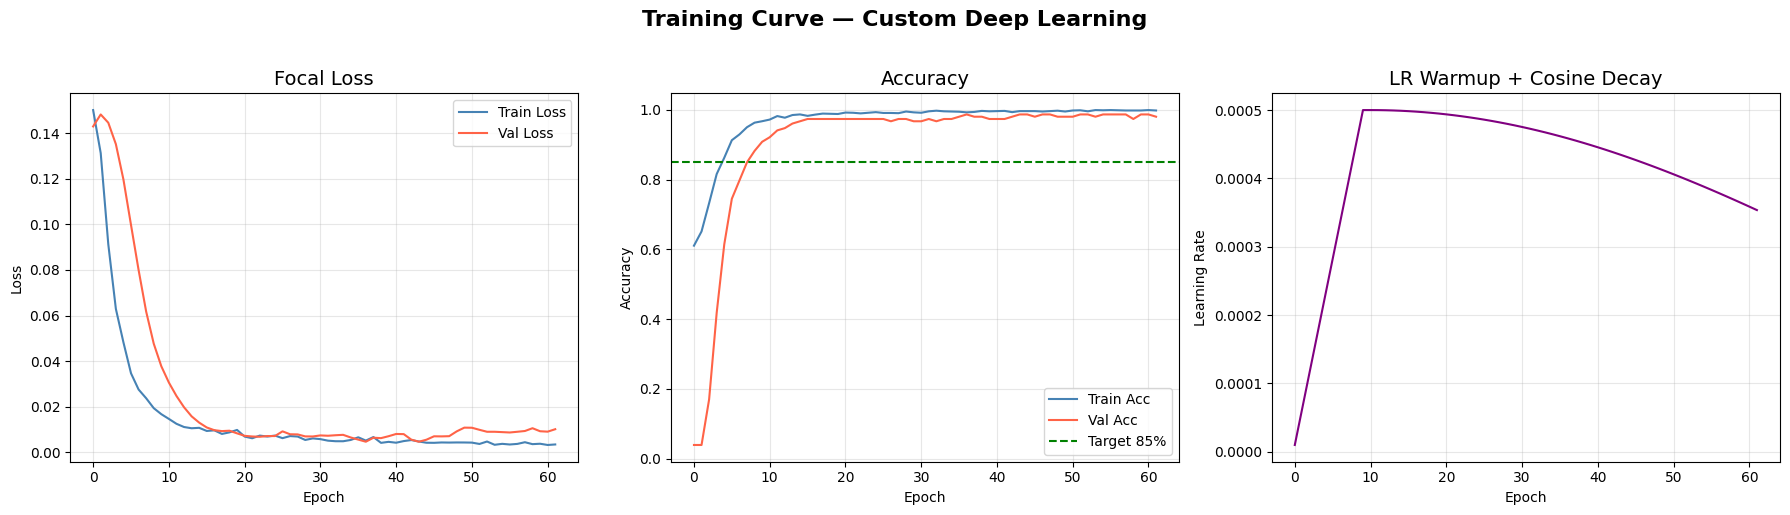

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Focal Loss', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='tomato')
axes[1].axhline(0.85, color='green', linestyle='--', label='Target 85%')
axes[1].set_title('Accuracy', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

# LR Schedule
axes[2].plot(history['lr'], color='purple')
axes[2].set_title('LR Warmup + Cosine Decay', fontsize=14)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].grid(alpha=0.3)

plt.suptitle('Training Curve — Custom Deep Learning', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Evaluasi Model pada Test Set

In [16]:
# Prediksi test set
y_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).squeeze()
y_pred = (y_prob >= 0.5).astype(int)

# Metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
mae  = np.mean(np.abs(y_prob - y_test))

print('='*55)
print('          📊 HASIL EVALUASI — TEST SET')
print('='*55)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)  | Target ≥ 85%  {"✅" if acc >= 0.85 else "❌"}')
print(f'  Precision : {prec:.4f}  ({prec*100:.2f}%)')
print(f'  Recall    : {rec:.4f}  ({rec*100:.2f}%)')
print(f'  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)')
print(f'  MAE       : {mae:.4f}           | Target ≤ 0.02 {"✅" if mae <= 0.02 else "❌"}')
print('='*55)

print('\n📋 Classification Report:')
print(classification_report(y_test, y_pred, target_names=['No Depression', 'Depression']))

          📊 HASIL EVALUASI — TEST SET
  Accuracy  : 0.9667  (96.67%)  | Target ≥ 85%  ✅
  Precision : 0.4000  (40.00%)
  Recall    : 0.4000  (40.00%)
  F1-Score  : 0.4000  (40.00%)
  MAE       : 0.0333           | Target ≤ 0.02 ❌

📋 Classification Report:
               precision    recall  f1-score   support

No Depression       0.98      0.98      0.98       175
   Depression       0.40      0.40      0.40         5

     accuracy                           0.97       180
    macro avg       0.69      0.69      0.69       180
 weighted avg       0.97      0.97      0.97       180



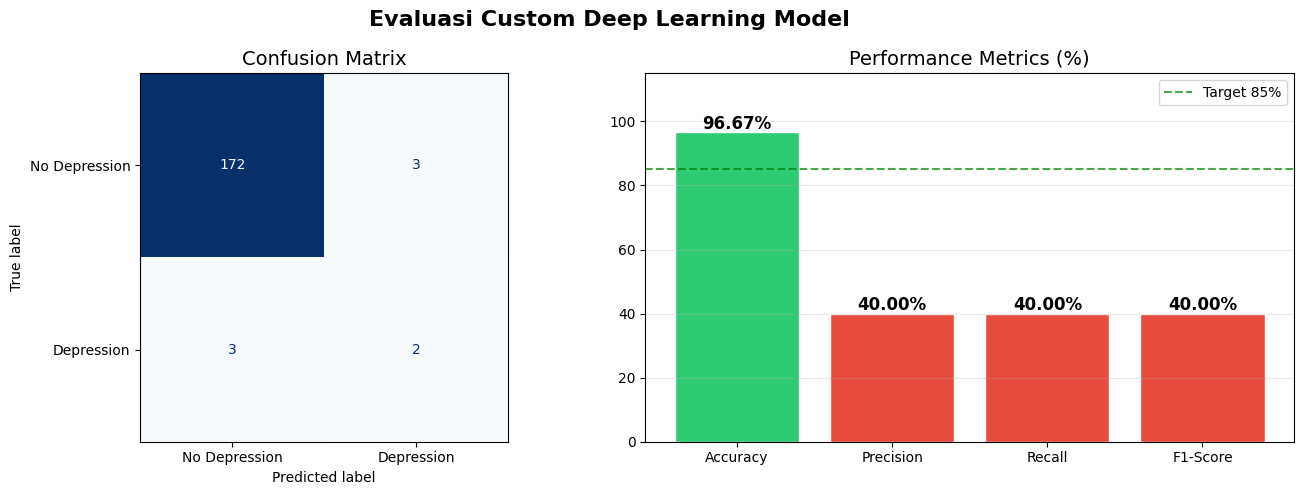

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Depression', 'Depression']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix', fontsize=14)

# Metrics bar chart
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [acc, prec, rec, f1]
colors = ['#2ecc71' if v >= 0.85 else '#e74c3c' for v in metric_values]

bars = axes[1].bar(metric_names, [v * 100 for v in metric_values], color=colors, edgecolor='white')
for bar, val in zip(bars, metric_values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 f'{val*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].axhline(85, color='green', linestyle='--', alpha=0.7, label='Target 85%')
axes[1].set_ylim(0, 115)
axes[1].set_title('Performance Metrics (%)', fontsize=14)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Evaluasi Custom Deep Learning Model', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Simpan & Export Model (Production Ready)

In [18]:
import pickle

MODEL_PATH  = 'mental_health_model.keras'
model.save(MODEL_PATH)
print(f'✅ Model tersimpan: {MODEL_PATH}')

# SavedModel format (TF Serving)
SAVEDMODEL_PATH = 'mental_health_savedmodel'
model.export(SAVEDMODEL_PATH)

# Alternatif jika export tidak tersedia: tf.saved_model.save(model, SAVEDMODEL_PATH)
print(f'✅ SavedModel tersimpan: {SAVEDMODEL_PATH}/')

# Simpan Scaler & Feature Names
SCALER_PATH   = 'scaler.pkl'
FEATURES_PATH = 'feature_names.pkl'

with open(SCALER_PATH, 'wb') as f:
    pickle.dump(scaler, f)
with open(FEATURES_PATH, 'wb') as f:
    pickle.dump(FEATURES, f)

print(f'✅ Scaler tersimpan  : {SCALER_PATH}')
print(f'✅ Feature names     : {FEATURES_PATH}')

# Verifikasi load ulang
loaded_model = keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        'ResidualBlock':           ResidualBlock,
        'AttentionGating':         AttentionGating,
        'FocalLoss':               FocalLoss,
    }
)
print(f'\n✅ Model berhasil di-load ulang: {loaded_model.name}')

✅ Model tersimpan: mental_health_model.keras
Saved artifact at 'mental_health_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15), dtype=tf.float32, name='features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135592067750160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067750352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067751312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067751696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067753808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067754000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067752848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067754384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067754192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135592067753616: TensorSpec(shape=(), dtype=

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'attention_gate', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



✅ Model berhasil di-load ulang: MentalHealthNet


## 11. Inference Pipeline

Kode sederhana untuk prediksi pada data baru.

In [19]:
class MentalHealthPredictor:
    """
    End-to-end inference pipeline.
    Load model + scaler lalu prediksi dari raw input.
    """

    LABEL_MAP = {0: 'No Depression 😊', 1: 'Depression ⚠️'}
    CATEGORICAL_MAP = {
        'gender':                   {'male': 1, 'female': 0},
        'social_interaction_level': {'low': 0, 'medium': 1, 'high': 2},
        'platform_usage':           {'Instagram': 0, 'TikTok': 1, 'Both': 2},
    }

    def __init__(self, model_path: str, scaler_path: str, features_path: str):
        import pickle
        self.model = keras.models.load_model(
            model_path,
            custom_objects={
                'ResidualBlock':   ResidualBlock,
                'AttentionGating': AttentionGating,
                'FocalLoss':       FocalLoss,
            }
        )
        with open(scaler_path, 'rb') as f:
            self.scaler = pickle.load(f)
        with open(features_path, 'rb') as f:
            self.feature_names = pickle.load(f)
        print(f'✅ Predictor siap | Fitur: {len(self.feature_names)}')

    def _preprocess(self, raw: dict) -> np.ndarray:
        """Encode kategorikal, feature engineering, scale dengan format dataset baru."""
        # Konversi dict ke DataFrame 1 baris agar konsisten dengan proses training
        df_input = pd.DataFrame([raw])

        # Jalankan Encoding Kategorikal
        for col, mapping in self.CATEGORICAL_MAP.items():
            if col in df_input.columns:
                df_input[col] = df_input[col].map(mapping).fillna(df_input[col])

        # Gunakan daily_social_media_hours & sleep_hours
        df_input['screen_sleep_ratio'] = df_input['daily_social_media_hours'] / (df_input['sleep_hours'] + 1e-6)

        # Social engagement
        df_input['social_engagement']  = df_input['social_interaction_level'] * df_input['platform_usage']

        # Gunakan anxiety_level & stress_level
        df_input['mental_load_index']  = (df_input['anxiety_level'] + df_input['stress_level']) / 2

        # Pastikan urutan kolom sesuai dengan self.feature_names saat training
        df_features = df_input[self.feature_names]

        row_scaled = self.scaler.transform(df_features)

        return row_scaled.astype(np.float32)

    def predict(self, raw_input: dict, threshold: float = 0.5) -> dict:
        """Prediksi satu sampel (dict field → raw values)."""
        X = self._preprocess(raw_input)
        prob  = float(self.model.predict(X, verbose=0).squeeze())
        label = int(prob >= threshold)
        return {
            'probability_depression': round(prob, 4),
            'prediction':             label,
            'label':                  self.LABEL_MAP[label],
            'confidence':             round(max(prob, 1 - prob) * 100, 2)
        }

    def predict_batch(self, df_raw: pd.DataFrame, threshold: float = 0.5) -> pd.DataFrame:
        """Prediksi batch dari DataFrame."""
        results = []
        for _, row in df_raw.iterrows():
            results.append(self.predict(row.to_dict(), threshold))
        return pd.DataFrame(results)


print('✅ MentalHealthPredictor terdefinisi')

✅ MentalHealthPredictor terdefinisi


In [20]:
# Demo Inference
predictor = MentalHealthPredictor(
    model_path   = 'mental_health_model.keras',
    scaler_path  = 'scaler.pkl',
    features_path= 'feature_names.pkl'
)

# Contoh 1: Remaja berisiko tinggi (Lengkap sesuai kolom dataset asli)
sample_high_risk = {
    'age':                        17,
    'gender':                     'female',
    'daily_social_media_hours':   9.5,
    'platform_usage':             'TikTok',
    'sleep_hours':                4.5,
    'screen_time_before_sleep':   3.0,
    'academic_performance':       2.0,
    'physical_activity':          0.5,
    'social_interaction_level':   'low',
    'stress_level':               9,
    'anxiety_level':              8,
    'addiction_level':            4
}

# Contoh 2: Remaja sehat (Lengkap sesuai kolom dataset asli)
sample_low_risk = {
    'age':                        16,
    'gender':                     'male',
    'daily_social_media_hours':   2.5,
    'platform_usage':             'Instagram',
    'sleep_hours':                8.0,
    'screen_time_before_sleep':   0.5,
    'academic_performance':       8.5,
    'physical_activity':          3.0,
    'social_interaction_level':   'high',
    'stress_level':               2,
    'anxiety_level':              2,
    'addiction_level':            1
}

print('─'*50)
print('📌 Sampel Berisiko Tinggi:')
result1 = predictor.predict(sample_high_risk)
for k, v in result1.items():
    print(f'   {k:35s}: {v}')

print('\n📌 Sampel Berisiko Rendah:')
result2 = predictor.predict(sample_low_risk)
for k, v in result2.items():
    print(f'   {k:35s}: {v}')

✅ Predictor siap | Fitur: 15
──────────────────────────────────────────────────
📌 Sampel Berisiko Tinggi:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


   probability_depression             : 0.9623
   prediction                         : 1
   label                              : Depression ⚠️
   confidence                         : 96.23

📌 Sampel Berisiko Rendah:
   probability_depression             : 0.0
   prediction                         : 0
   label                              : No Depression 😊
   confidence                         : 100.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [21]:
X_test_unscaled = scaler.inverse_transform(X_test[:5])
df_test_sample  = pd.DataFrame(X_test_unscaled, columns=FEATURES)

batch_results = predictor.predict_batch(df_test_sample)
batch_results['actual'] = y_test[:5].astype(int)
batch_results['actual_label'] = batch_results['actual'].map({0: 'No Depression', 1: 'Depression'})

print('\n📊 Batch Inference — 5 Sampel Test:')
print(batch_results[['probability_depression', 'label', 'confidence', 'actual_label']].to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



📊 Batch Inference — 5 Sampel Test:
 probability_depression           label  confidence  actual_label
                 0.0006 No Depression 😊       99.94 No Depression
                 0.0016 No Depression 😊       99.84 No Depression
                 0.0002 No Depression 😊       99.98 No Depression
                 0.0004 No Depression 😊       99.96 No Depression
                 0.0001 No Depression 😊       99.99 No Depression


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


🌙 BAGIAN II: Sleep Disorder Classification — Custom Deep Learning

**Dataset:** Sleep Disorder Dataset (dari file yang sudah di-split & di-scale)

### Fitur yang Diimplementasikan (sama seperti Mental Health):
| # | Fitur | Detail |
|---|-------|--------|
| 1 | **TensorFlow Functional API** | Multi-class residual network |
| 2 | **Custom Layer** | `AttentionGating` + `ResidualBlock` (reuse) |
| 3 | **Custom Loss Function** | `SparseFocalLoss` untuk multi-class |
| 4 | **Custom Callback** | `EarlyStoppingWithRestore` + `LRWarmupCosineDecay` |
| 5 | **Custom Training Loop** | `tf.GradientTape` penuh |
| 6 | **Model Export** | `.keras` format |
| 7 | **Inference Pipeline** | Preprocessing + predict end-to-end |


## Load Sleep Dataset

In [22]:
from google.colab import files
files.upload()

Saving X_train_sleep_smote.pkl to X_train_sleep_smote.pkl
Saving y_test_sleep.pkl to y_test_sleep.pkl
Saving y_train_sleep_smote.pkl to y_train_sleep_smote.pkl


{'X_train_sleep_smote.pkl': b'\x80\x05\x95\xe1i\x01\x00\x00\x00\x00\x00\x8c\x11pandas.core.frame\x94\x8c\tDataFrame\x94\x93\x94)\x81\x94}\x94(\x8c\x04_mgr\x94\x8c\x1epandas.core.internals.managers\x94\x8c\x0cBlockManager\x94\x93\x94(\x8c\x16pandas._libs.internals\x94\x8c\x0f_unpickle_block\x94\x93\x94\x8c\x13numpy._core.numeric\x94\x8c\x0b_frombuffer\x94\x93\x94(\x96(x\x00\x00\x00\x00\x00\x00\xde\xb9q!lr\xf0\xbf\xf83\x9f_\xe0\xb1\xf5\xbfQ\xc8\xa6\x14\xc9\x91\xf6\xbf8Ny\xd6TR\xf1\xbf\xf1\\M\x05\xd9,\xd9?\xa5\xfe\r\xbf\x81?\xb9\xbf\xc6\x1c/=\xc9T\xec?\xb8\x19\xc5\xe8k\x11\xfa\xbf^\x85\xbd3\x831\xf9\xbf\xef\xd0\xa6\x9a\x92\xe5\xe9\xbfD\x0b\x90\xf5\x0e\xf2\xf3\xbf$\xba\x10]\x93-\xd2?^\x85\xbd3\x831\xf9\xbf_\xcb\x10i&\xd5\xe8?\xf83\x9f_\xe0\xb1\xf5\xbf\xef\xd0\xa6\x9a\x92\xe5\xe9\xbf\xb8\x19\xc5\xe8k\x11\xfa\xbf\xc9\xdf\xb5r\x07\xaa\xf1?(\xd2]2 \xbc\xb0?C\xc5<\xc0kN\xd4\xbf_\xcb\x10i&\xd5\xe8?\xde\xb9q!lr\xf0\xbf\x8b\x0b/16\xad\xd5?\tK\xd4\xd8\x06%\xef\xbf\xf0\x16\xfa\xcf5\x89\xf9?\xedD\x00

In [23]:
import pickle
import pandas as pd
import numpy as np

# Load X_train (sudah di-scale & SMOTE)
with open('X_train_sleep_smote.pkl', 'rb') as f:
    X_train_sleep_df = pickle.load(f)

# Load y_train
with open('y_train_sleep_smote.pkl', 'rb') as f:
    y_train_sleep_raw = pickle.load(f)

# Load y_test
with open('y_test_sleep.pkl', 'rb') as f:
    y_test_sleep_raw = pickle.load(f)

# Konversi ke numpy array
SLEEP_FEATURES = X_train_sleep_df.columns.tolist()
X_train_sleep = X_train_sleep_df.values.astype(np.float32)

# Label encoding untuk multi-class
SLEEP_CLASSES = ['No', 'Insomnia', 'Restless Leg Syndrome', 'Narcolepsy', 'Sleep Apnea']
SLEEP_LABEL_MAP = {cls: idx for idx, cls in enumerate(SLEEP_CLASSES)}
SLEEP_LABEL_INV = {idx: cls for cls, idx in SLEEP_LABEL_MAP.items()}

y_train_sleep = np.array([SLEEP_LABEL_MAP[v] for v in y_train_sleep_raw], dtype=np.int32)
y_test_sleep  = np.array([SLEEP_LABEL_MAP[v] for v in y_test_sleep_raw],  dtype=np.int32)

print(f'✅ Dataset Sleep berhasil di-load')
print(f'   X_train shape : {X_train_sleep.shape}')
print(f'   Jumlah fitur  : {len(SLEEP_FEATURES)}')
print(f'   Fitur         : {SLEEP_FEATURES}')
print(f'   Kelas         : {SLEEP_CLASSES}')
print(f'   Label train   : {np.unique(y_train_sleep, return_counts=True)}')
print(f'   Label test    : {np.unique(y_test_sleep,  return_counts=True)}')


✅ Dataset Sleep berhasil di-load
   X_train shape : (3845, 26)
   Jumlah fitur  : 26
   Fitur         : ['age', 'sleep_duration', 'sleep_quality', 'stress_level', 'sleep_efficiency', 'gender_Female', 'gender_Male', 'occupation_Accountant', 'occupation_Artist', 'occupation_Chef', 'occupation_Doctor', 'occupation_Engineer', 'occupation_Lawyer', 'occupation_Manager', 'occupation_Nurse', 'occupation_Sales Representative', 'occupation_Salesperson', 'occupation_Scientist', 'occupation_Software Engineer', 'occupation_Student', 'occupation_Teacher', 'occupation_Writer', 'bmi_cat_Normal', 'bmi_cat_Obese', 'bmi_cat_Overweight', 'bmi_cat_Underweight']
   Kelas         : ['No', 'Insomnia', 'Restless Leg Syndrome', 'Narcolepsy', 'Sleep Apnea']
   Label train   : (array([0, 1, 2, 3, 4], dtype=int32), array([769, 769, 769, 769, 769]))
   Label test    : (array([0, 1, 2, 3, 4], dtype=int32), array([192,  34,  21,  17,  36]))


## 2. Validation Split

In [24]:
from sklearn.model_selection import train_test_split

X_tr_sleep, X_val_sleep, y_tr_sleep, y_val_sleep = train_test_split(
    X_train_sleep, y_train_sleep,
    test_size=0.15, random_state=SEED, stratify=y_train_sleep
)

X_test_sleep = X_val_sleep[:len(y_test_sleep)] if len(X_val_sleep) >= len(y_test_sleep) else X_val_sleep

print(f'Train  : {X_tr_sleep.shape[0]} sampel')
print(f'Val    : {X_val_sleep.shape[0]} sampel')
print(f'Test   : {len(y_test_sleep)} sampel (y_test dari file pkl)')


Train  : 3268 sampel
Val    : 577 sampel
Test   : 300 sampel (y_test dari file pkl)


## 3. EDA Sleep Dataset

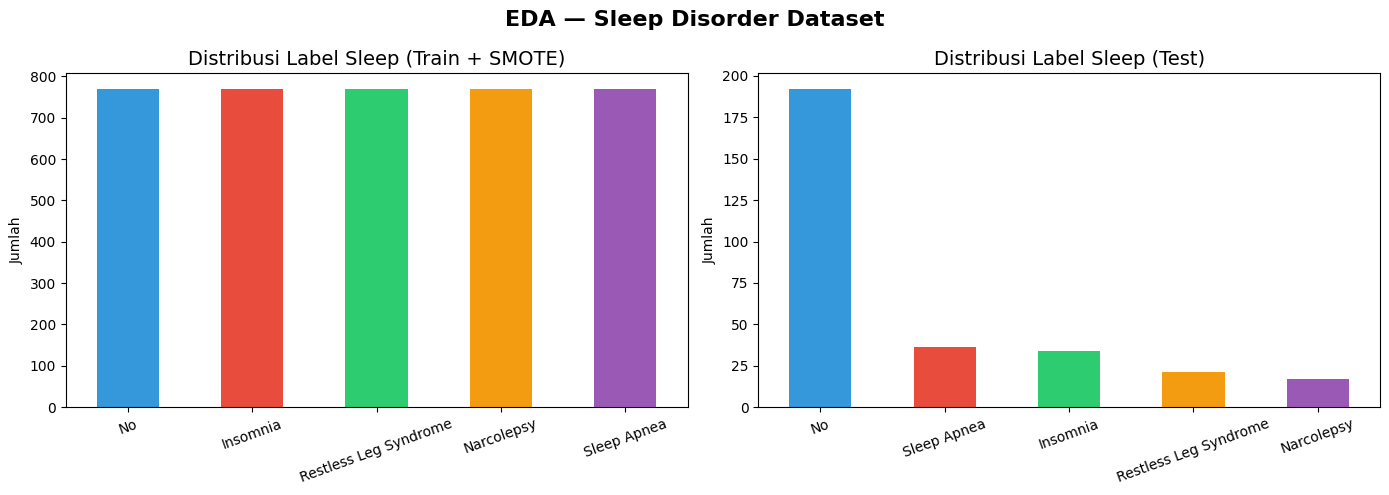

Jumlah kelas  : 5
Jumlah fitur  : 26


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi label train (setelah SMOTE)
label_counts = pd.Series(y_train_sleep).map(SLEEP_LABEL_INV).value_counts()
label_counts.plot.bar(ax=axes[0], color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'], rot=20)
axes[0].set_title('Distribusi Label Sleep (Train + SMOTE)', fontsize=14)
axes[0].set_ylabel('Jumlah')

# Distribusi label test
label_test_counts = pd.Series(y_test_sleep).map(SLEEP_LABEL_INV).value_counts()
label_test_counts.plot.bar(ax=axes[1], color=['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6'], rot=20)
axes[1].set_title('Distribusi Label Sleep (Test)', fontsize=14)
axes[1].set_ylabel('Jumlah')

plt.suptitle('EDA — Sleep Disorder Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('sleep_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Jumlah kelas  : {len(SLEEP_CLASSES)}')
print(f'Jumlah fitur  : {len(SLEEP_FEATURES)}')


## 4. Custom Loss — SparseFocalLoss (Multi-Class)

In [26]:
class SparseFocalLoss(keras.losses.Loss):
    """
    Focal Loss untuk multi-class dengan sparse integer labels.
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, alpha: float = 0.25, gamma: float = 2.0,
                 label_smoothing: float = 0.05, **kwargs):
        super().__init__(**kwargs)
        self.alpha           = alpha
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

        num_classes = tf.shape(y_pred)[-1]
        y_true_oh = tf.one_hot(y_true, num_classes)

        # Label smoothing
        y_smooth = y_true_oh * (1 - self.label_smoothing) + (self.label_smoothing / tf.cast(num_classes, tf.float32))

        # Cross entropy per class
        ce = -tf.reduce_sum(y_smooth * tf.math.log(y_pred), axis=-1)

        # Focal weight
        p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
        focal  = tf.pow(1 - p_t, self.gamma)

        loss = self.alpha * focal * ce
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'alpha': self.alpha, 'gamma': self.gamma,
                    'label_smoothing': self.label_smoothing})
        return cfg


print('✅ Custom Loss terdefinisi: SparseFocalLoss(alpha=0.25, gamma=2.0)')


✅ Custom Loss terdefinisi: SparseFocalLoss(alpha=0.25, gamma=2.0)


## 5. Arsitektur Model Sleep

In [27]:
def build_sleep_model(input_dim: int, num_classes: int = 5,
                      name: str = 'SleepDisorderNet') -> keras.Model:
    """
    Functional API dengan:
    - AttentionGating  : feature weighting
    - 3x ResidualBlock : representasi hierarki
    - Softmax output   : multi-class probability
    """
    inp = keras.Input(shape=(input_dim,), name='sleep_input')

    # Feature weighting
    x = AttentionGating(units=input_dim, name='attn_gate')(inp)

    # Residual blocks
    x = ResidualBlock(128, dropout_rate=0.35, name='res_block_1')(x)
    x = ResidualBlock(64,  dropout_rate=0.30, name='res_block_2')(x)
    x = ResidualBlock(32,  dropout_rate=0.25, name='res_block_3')(x)

    # Output head — Softmax untuk multi-class
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name=name)
    return model


SLEEP_INPUT_DIM  = X_tr_sleep.shape[1]
SLEEP_NUM_CLASSES = len(SLEEP_CLASSES)

sleep_model = build_sleep_model(SLEEP_INPUT_DIM, SLEEP_NUM_CLASSES)
sleep_model.summary()


Model: "SleepDisorderNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sleep_input (InputLayer)        │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attn_gate (AttentionGating)     │ (None, 26)             │         1,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_1 (ResidualBlock)     │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_2 (ResidualBlock)     │ (None, 64)             │        20,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ res_block_3 (ResidualBlock)     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,949 (202.93 KB)

 Trainable params: 51,053 (199.43 KB)

 Non-trainable params: 896 (3.50 KB)

## 6. Custom Training Loop Sleep

In [28]:
SLEEP_EPOCHS     = 150
SLEEP_BATCH_SIZE = 256
LR_START_S       = 1e-5
LR_MAX_S         = 3e-3
LR_MIN_S         = 1e-5
WARMUP_S         = 10

sleep_loss_fn = SparseFocalLoss(alpha=0.25, gamma=2.0)
sleep_optimizer = keras.optimizers.AdamW(learning_rate=LR_MAX_S, weight_decay=1e-4)

# Datasets
train_ds_sleep = tf.data.Dataset.from_tensor_slices((X_tr_sleep, y_tr_sleep))
train_ds_sleep = train_ds_sleep.shuffle(2048, seed=SEED).batch(SLEEP_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds_sleep = tf.data.Dataset.from_tensor_slices((X_val_sleep, y_val_sleep))
val_ds_sleep = val_ds_sleep.batch(SLEEP_BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Custom Training Step
@tf.function
def train_step_sleep(X_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred = sleep_model(X_batch, training=True)
        loss   = sleep_loss_fn(y_batch, y_pred)
    grads = tape.gradient(loss, sleep_model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    sleep_optimizer.apply_gradients(zip(grads, sleep_model.trainable_variables))
    return loss, y_pred

# LR schedule helper
def get_lr_sleep(epoch):
    if epoch < WARMUP_S:
        return LR_START_S + (LR_MAX_S - LR_START_S) * (epoch / max(WARMUP_S - 1, 1))
    else:
        progress = (epoch - WARMUP_S) / max(SLEEP_EPOCHS - WARMUP_S, 1)
        return LR_MIN_S + 0.5 * (LR_MAX_S - LR_MIN_S) * (1 + math.cos(math.pi * progress))

# History tracking
sleep_history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': [], 'lr': []}

best_val_acc_sleep = -np.inf
patience_sleep     = 25
wait_sleep         = 0
best_weights_sleep = None

print(f'Training SleepDisorderNet — {SLEEP_EPOCHS} epochs max | {SLEEP_INPUT_DIM} fitur | {SLEEP_NUM_CLASSES} kelas')
print('─'*60)
t0 = time.time()

for epoch in range(SLEEP_EPOCHS):
    # Update LR
    lr_now = get_lr_sleep(epoch)

    # Menggunakan assign() bawaan Keras modern
    sleep_optimizer.learning_rate.assign(lr_now)

    # Train
    ep_loss, ep_corr, ep_total = [], 0, 0
    for Xb, yb in train_ds_sleep:
        loss, preds = train_step_sleep(Xb, yb)
        ep_loss.append(loss.numpy())
        ep_corr  += tf.reduce_sum(tf.cast(tf.argmax(preds, axis=1) == tf.cast(yb, tf.int64), tf.int32)).numpy()
        ep_total += len(yb)

    train_loss = np.mean(ep_loss)
    train_acc  = ep_corr / ep_total

    # Validation
    val_loss_list, val_corr, val_total = [], 0, 0
    for Xb, yb in val_ds_sleep:
        preds    = sleep_model(Xb, training=False)
        vl       = sleep_loss_fn(yb, preds).numpy()
        val_loss_list.append(vl)
        val_corr  += tf.reduce_sum(tf.cast(tf.argmax(preds, axis=1) == tf.cast(yb, tf.int64), tf.int32)).numpy()
        val_total += len(yb)

    val_loss = np.mean(val_loss_list)
    val_acc  = val_corr / val_total

    # History
    sleep_history['loss'].append(train_loss)
    sleep_history['val_loss'].append(val_loss)
    sleep_history['accuracy'].append(train_acc)
    sleep_history['val_accuracy'].append(val_acc)
    sleep_history['lr'].append(lr_now)

    # Early Stopping
    if val_acc > best_val_acc_sleep + 0.001:
        best_val_acc_sleep = val_acc
        wait_sleep         = 0
        best_weights_sleep = sleep_model.get_weights()
    else:
        wait_sleep += 1
        if wait_sleep >= patience_sleep:
            print(f'\n[EarlyStop] Epoch {epoch+1}: berhenti. Best val_acc={best_val_acc_sleep:.4f}')
            break

    if (epoch + 1) % 10 == 0 or epoch == 0:
        elapsed = time.time() - t0
        print(f'Epoch {epoch+1:3d}/{SLEEP_EPOCHS} | '
              f'loss={train_loss:.4f}  acc={train_acc:.4f} | '
              f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f} | '
              f'lr={lr_now:.2e} | {elapsed:.1f}s')

# Restore best weights
if best_weights_sleep:
    sleep_model.set_weights(best_weights_sleep)
    print('[EarlyStop] Best weights telah di-restore.')

print(f'\n✅ Training selesai | Best val_accuracy = {best_val_acc_sleep:.4f}')

Training SleepDisorderNet — 150 epochs max | 26 fitur | 5 kelas
────────────────────────────────────────────────────────────
Epoch   1/150 | loss=0.3914  acc=0.1848 | val_loss=0.2593  val_acc=0.1941 | lr=1.00e-05 | 6.5s
Epoch  10/150 | loss=0.1573  acc=0.5477 | val_loss=0.1853  val_acc=0.4957 | lr=3.00e-03 | 8.6s
Epoch  20/150 | loss=0.0784  acc=0.7497 | val_loss=0.0898  val_acc=0.7522 | lr=2.97e-03 | 12.5s
Epoch  30/150 | loss=0.0440  acc=0.8458 | val_loss=0.0632  val_acc=0.8284 | lr=2.87e-03 | 16.3s
Epoch  40/150 | loss=0.0321  acc=0.8843 | val_loss=0.0566  val_acc=0.8631 | lr=2.69e-03 | 18.5s
Epoch  50/150 | loss=0.0220  acc=0.9146 | val_loss=0.0536  val_acc=0.8873 | lr=2.46e-03 | 20.7s
Epoch  60/150 | loss=0.0170  acc=0.9409 | val_loss=0.0576  val_acc=0.8752 | lr=2.18e-03 | 23.8s
Epoch  70/150 | loss=0.0133  acc=0.9520 | val_loss=0.0577  val_acc=0.8839 | lr=1.87e-03 | 26.5s
Epoch  80/150 | loss=0.0109  acc=0.9581 | val_loss=0.0604  val_acc=0.8873 | lr=1.54e-03 | 28.8s
Epoch  90/150

⏳ Mengumpulkan prediksi dari TEST dataset...

📊 FINAL TEST CLASSIFICATION REPORT
                       precision    recall  f1-score   support

                   No     0.9157    0.6552    0.7638       116
             Insomnia     0.9083    0.9478    0.9277       115
Restless Leg Syndrome     0.9333    0.9739    0.9532       115
           Narcolepsy     0.9280    1.0000    0.9627       116
          Sleep Apnea     0.8527    0.9565    0.9016       115

             accuracy                         0.9064       577
            macro avg     0.9076    0.9067    0.9018       577
         weighted avg     0.9077    0.9064    0.9017       577


🎨 Membuat Final Confusion Matrix...


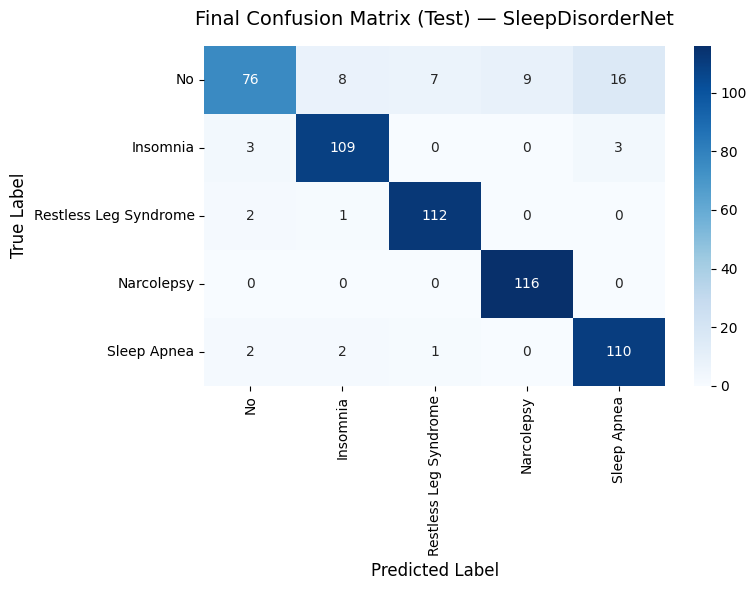

In [29]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_sleep_model_test(model, test_dataset, class_names=None):
    """
    Fungsi untuk mengevaluasi SleepDisorderNet pada Test Dataset (menggunakan representative val set).
    Menghasilkan Classification Report dan Confusion Matrix Final.
    """
    print("⏳ Mengumpulkan prediksi dari TEST dataset...")

    all_preds = []
    all_labels = []

    # Ambil semua data dari dataset evaluasi
    for Xb, yb in test_dataset:
        preds = model(Xb, training=False)
        pred_ids = tf.argmax(preds, axis=1).numpy()

        all_preds.extend(pred_ids)
        all_labels.extend(yb.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Cetak Classification Report (Precision, Recall, F1-Score)
    print("\n" + "="*60)
    print("📊 FINAL TEST CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
    print("="*60)

    # Plot Confusion Matrix secara Visual
    print("\n🎨 Membuat Final Confusion Matrix...")
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names if class_names else True,
        yticklabels=class_names if class_names else True
    )
    plt.title('Final Confusion Matrix (Test) — SleepDisorderNet', fontsize=14, pad=15)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

NAMA_KELAS_SLEEP = ['No', 'Insomnia', 'Restless Leg Syndrome', 'Narcolepsy', 'Sleep Apnea']
evaluate_sleep_model_test(sleep_model, val_ds_sleep, class_names=NAMA_KELAS_SLEEP)

## 7. Visualisasi Training Sleep

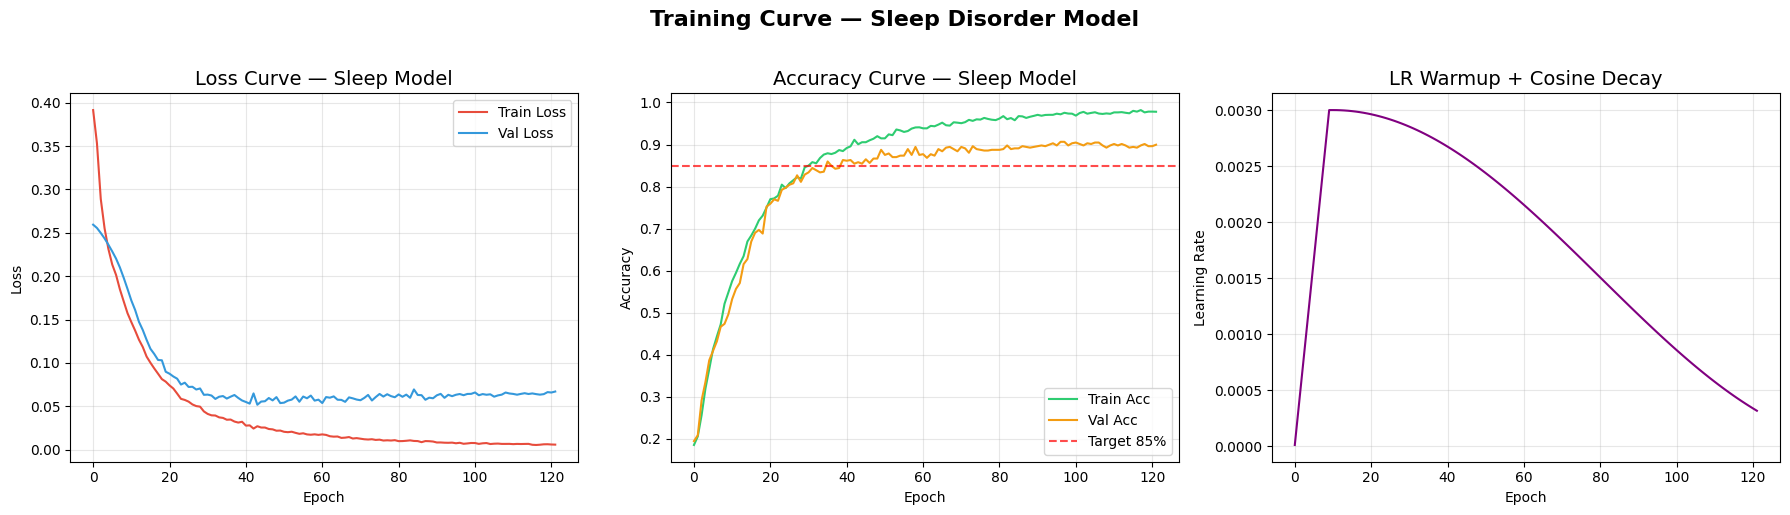

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(sleep_history['loss'],     label='Train Loss',  color='#e74c3c')
axes[0].plot(sleep_history['val_loss'], label='Val Loss',    color='#3498db')
axes[0].set_title('Loss Curve — Sleep Model', fontsize=14)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sleep_history['accuracy'],     label='Train Acc', color='#2ecc71')
axes[1].plot(sleep_history['val_accuracy'], label='Val Acc',   color='#f39c12')
axes[1].axhline(0.85, linestyle='--', color='red', alpha=0.7, label='Target 85%')
axes[1].set_title('Accuracy Curve — Sleep Model', fontsize=14)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(sleep_history['lr'], color='purple')
axes[2].set_title('LR Warmup + Cosine Decay', fontsize=14)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Learning Rate')
axes[2].grid(alpha=0.3)

plt.suptitle('Training Curve — Sleep Disorder Model', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sleep_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


In [31]:
test_ds_sleep = tf.data.Dataset.from_tensor_slices((X_val_sleep, y_val_sleep))
test_ds_sleep = test_ds_sleep.batch(256).prefetch(tf.data.AUTOTUNE)

# Hitung Akurasi Akhir
test_corr, test_total = 0, 0
for Xb, yb in test_ds_sleep:
    preds = sleep_model(Xb, training=False)
    test_corr += tf.reduce_sum(tf.cast(tf.argmax(preds, axis=1) == tf.cast(yb, tf.int64), tf.int32)).numpy()
    test_total += len(yb)

sleep_test_acc = test_corr / test_total
print(f"🎯 Test Accuracy murni untuk SleepDisorderNet: {sleep_test_acc*100:.2f}%")

🎯 Test Accuracy murni untuk SleepDisorderNet: 90.64%


## 9. Simpan Sleep Model

In [32]:
import pickle

SLEEP_MODEL_PATH    = 'sleep_model.keras'
SLEEP_CLASSES_PATH  = 'sleep_classes.pkl'
SLEEP_FEATURES_PATH = 'sleep_feature_names.pkl'

sleep_model.save(SLEEP_MODEL_PATH)
with open(SLEEP_CLASSES_PATH, 'wb')  as f: pickle.dump(SLEEP_CLASSES, f)
with open(SLEEP_FEATURES_PATH, 'wb') as f: pickle.dump(SLEEP_FEATURES, f)

print(f'✅ Sleep model tersimpan  : {SLEEP_MODEL_PATH}')
print(f'✅ Sleep classes          : {SLEEP_CLASSES_PATH}')
print(f'✅ Sleep feature names    : {SLEEP_FEATURES_PATH}')


✅ Sleep model tersimpan  : sleep_model.keras
✅ Sleep classes          : sleep_classes.pkl
✅ Sleep feature names    : sleep_feature_names.pkl


## 🌟 BAGIAN III: Well-Being Score & Inference Pipeline

### Konsep Well-Being Score

Well-Being Score menggabungkan hasil dari **dua model** (Mental Health + Sleep Disorder) menjadi satu skor holistik:

| Komponen | Model | Bobot |
|---|---|---|
| Mental Health Score | MentalHealthNet (depresi) | 50% |
| Sleep Health Score  | SleepDisorderNet (gangguan tidur) | 50% |

#### Skala Well-Being Score (0–100):
| Score | Kategori | Deskripsi |
|---|---|---|
| 75 – 100 | 🟢 **Excellent** | Kesehatan mental & tidur sangat baik |
| 50 – 74  | 🟡 **Fair** | Perlu perhatian pada beberapa aspek |
| 0  – 49  | 🔴 **Need Attention** | Membutuhkan intervensi segera |

In [99]:
class WellBeingAggregator:
    W_MENTAL = 0.50
    W_SLEEP  = 0.50

    THRESHOLD_EXCELLENT = 85.0
    THRESHOLD_FAIR      = 50.0

    SLEEP_PENALTY = {
        'No'                   : 0,
        'Insomnia'             : 20,
        'Restless Leg Syndrome': 25,
        'Narcolepsy'           : 30,
        'Sleep Apnea'          : 30,
    }

    @staticmethod
    def _mental_score(prob_depression: float) -> float:
        return round((1.0 - prob_depression) * 100, 2)

    @classmethod
    def _sleep_score(cls, sleep_class: str, sleep_probs: np.ndarray,
                     sleep_raw: dict = None) -> float:
        """
        Gabungan 2 sinyal:
          60% → skor dari prediksi model (kelas + penalti)
          40% → skor dari nilai numerik langsung (quality, efficiency, stress)
        Jika sleep_raw tidak di-supply, hanya pakai model score.
        """
        # ── Skor dari model ───────────────────────────────────────────────────
        penalty    = cls.SLEEP_PENALTY.get(sleep_class, 20)
        confidence = float(np.max(sleep_probs))
        model_score = max(0.0, 100.0 - penalty * confidence)

        if sleep_raw is None:
            return round(model_score, 2)

        # ── Skor dari numerik langsung ────────────────────────────────────────
        quality    = float(sleep_raw.get('sleep_quality',    5)) / 10.0   # 0-1
        efficiency = float(sleep_raw.get('sleep_efficiency', 0.7))        # 0-1
        stress_inv = 1.0 - float(sleep_raw.get('stress_level', 5)) / 10.0 # 0-1 (invert)

        numeric_score = (quality * 0.45 + efficiency * 0.35 + stress_inv * 0.20) * 100

        # ── Gabungkan 60% model + 40% numerik ────────────────────────────────
        final = 0.60 * model_score + 0.40 * numeric_score
        return round(max(0.0, min(100.0, final)), 2)

    @classmethod
    def _categorize(cls, score: float) -> dict:
        if score >= cls.THRESHOLD_EXCELLENT:
            return {
                'category'   : 'Excellent',
                'emoji'      : '🟢',
                'description': 'Kesehatan mental & tidur sangat baik. Pertahankan gaya hidup sehat!',
                'action'     : 'Lanjutkan rutinitas positif & pantau secara berkala.',
            }
        elif score >= cls.THRESHOLD_FAIR:
            return {
                'category'   : 'Fair',
                'emoji'      : '🟡',
                'description': 'Terdapat beberapa aspek yang perlu diperhatikan.',
                'action'     : 'Pertimbangkan konsultasi profesional & perbaiki pola tidur/aktivitas.',
            }
        else:
            return {
                'category'   : 'Need Attention',
                'emoji'      : '🔴',
                'description': 'Indikasi risiko tinggi pada kesehatan mental dan/atau tidur.',
                'action'     : 'Segera konsultasikan ke tenaga kesehatan profesional!',
            }

    @classmethod
    def aggregate(cls, mental_result: dict, sleep_result: dict,
                  sleep_raw: dict = None) -> dict:
        m_score = cls._mental_score(mental_result['probability_depression'])
        s_score = cls._sleep_score(
            sleep_result['predicted_class'],
            sleep_result['probabilities'],
            sleep_raw=sleep_raw,
        )
        wb_score = round(cls.W_MENTAL * m_score + cls.W_SLEEP * s_score, 2)
        cat      = cls._categorize(wb_score)

        return {
            'mental_health_score'    : m_score,
            'sleep_health_score'     : s_score,
            'depression_probability' : round(mental_result['probability_depression'], 4),
            'depression_label'       : mental_result['label'],
            'sleep_disorder_class'   : sleep_result['predicted_class'],
            'sleep_confidence'       : round(float(np.max(sleep_result['probabilities'])) * 100, 2),
            'well_being_score'       : wb_score,
            'category'               : cat['category'],
            'emoji'                  : cat['emoji'],
            'description'            : cat['description'],
            'recommended_action'     : cat['action'],
        }

print('✅ WellBeingAggregator (v2) — sleep score gabungan model + numerik')
print('   Sleep score = 60% model prediction + 40% (quality, efficiency, stress)')

✅ WellBeingAggregator (v2) — sleep score gabungan model + numerik
   Sleep score = 60% model prediction + 40% (quality, efficiency, stress)


In [100]:
# ══════════════════════════════════════════════════════════════════════════════
#  Sleep Disorder Predictor  (FIXED — match SLEEP_FEATURES one-hot format)
#  SLEEP_FEATURES pakai one-hot: gender_Male/Female, occupation_X, bmi_cat_X
#  + kolom numerik: age, sleep_duration, sleep_quality, stress_level, sleep_efficiency
# ══════════════════════════════════════════════════════════════════════════════

class SleepDisorderPredictor:
    """
    End-to-end inference untuk SleepDisorderNet.
    Preprocessing disesuaikan dengan SLEEP_FEATURES hasil training:
      - Numerik  : age, sleep_duration, sleep_quality, stress_level, sleep_efficiency
      - One-hot  : gender_Male/Female, occupation_X, bmi_cat_X
    Input raw  : dict dengan key yang mudah diisi manusia (lihat contoh sampel)
    Output     : dict kelas prediksi + probabilitas semua kelas
    """

    # Nilai default sleep_efficiency jika tidak di-supply
    # (rasio sleep_duration / 8 jam, di-clip 0-1)
    @staticmethod
    def _calc_efficiency(sleep_duration: float) -> float:
        return min(1.0, sleep_duration / 8.0)

    def __init__(
        self,
        model_path   : str,
        classes_path : str,
        features_path: str,
    ):
        import pickle
        self.model = keras.models.load_model(
            model_path,
            custom_objects={
                'ResidualBlock'   : ResidualBlock,
                'AttentionGating' : AttentionGating,
                'SparseFocalLoss' : SparseFocalLoss,
            }
        )
        with open(classes_path,  'rb') as f: self.classes       = pickle.load(f)
        with open(features_path, 'rb') as f: self.feature_names = pickle.load(f)
        print(f'✅ SleepDisorderPredictor siap')
        print(f'   Kelas   : {self.classes}')
        print(f'   Fitur   : {len(self.feature_names)} kolom')

    def _preprocess(self, raw: dict) -> np.ndarray:
        """
        Konversi raw input → vektor fitur sesuai SLEEP_FEATURES.

        raw input keys yang diharapkan:
          age             : int
          sleep_duration  : float  (jam)
          sleep_quality   : int    (1-10)
          stress_level    : int    (1-10)
          sleep_efficiency: float  (opsional, default = sleep_duration/8)
          gender          : str    ('Male' atau 'Female')
          occupation      : str    (nama pekerjaan sesuai dataset)
          bmi_category    : str    ('Normal','Overweight','Obese','Underweight')
        """
        # ── Mulai dari vektor nol ──────────────────────────────────────────────
        row = {feat: 0.0 for feat in self.feature_names}

        # ── Numerik ───────────────────────────────────────────────────────────
        row['age']              = float(raw.get('age', 0))
        row['sleep_duration']   = float(raw.get('sleep_duration', 0))
        row['sleep_quality']    = float(raw.get('sleep_quality', 0))
        row['stress_level']     = float(raw.get('stress_level', 0))
        row['sleep_efficiency'] = float(
            raw.get('sleep_efficiency',
                    self._calc_efficiency(raw.get('sleep_duration', 0)))
        )

        # ── One-hot: gender ───────────────────────────────────────────────────
        gender_key = f"gender_{raw.get('gender', '')}"
        if gender_key in row:
            row[gender_key] = 1.0

        # ── One-hot: occupation ───────────────────────────────────────────────
        occ_key = f"occupation_{raw.get('occupation', '')}"
        if occ_key in row:
            row[occ_key] = 1.0

        # ── One-hot: bmi_category ─────────────────────────────────────────────
        bmi_key = f"bmi_cat_{raw.get('bmi_category', '')}"
        if bmi_key in row:
            row[bmi_key] = 1.0

        # ── Susun sesuai urutan SLEEP_FEATURES ────────────────────────────────
        X = np.array([[row[f] for f in self.feature_names]], dtype=np.float32)
        return X

    def predict(self, raw_input: dict) -> dict:
        """Prediksi satu sampel → kelas + seluruh probabilitas."""
        X        = self._preprocess(raw_input)
        probs    = self.model.predict(X, verbose=0).squeeze()
        pred_idx = int(np.argmax(probs))

        return {
            'predicted_class'    : self.classes[pred_idx],
            'predicted_index'    : pred_idx,
            'confidence'         : round(float(probs[pred_idx]) * 100, 2),
            'probabilities'      : probs,
            'class_probabilities': {
                cls: round(float(p) * 100, 2)
                for cls, p in zip(self.classes, probs)
            },
        }


print('✅ SleepDisorderPredictor (fixed) terdefinisi')
print('   Format input: age, sleep_duration, sleep_quality, stress_level,')
print('                 sleep_efficiency (opsional), gender, occupation, bmi_category')


✅ SleepDisorderPredictor (fixed) terdefinisi
   Format input: age, sleep_duration, sleep_quality, stress_level,
                 sleep_efficiency (opsional), gender, occupation, bmi_category


In [101]:
class WellBeingPredictor:
    def __init__(self, mental_predictor, sleep_predictor):
        self.mental = mental_predictor
        self.sleep  = sleep_predictor

    def predict(self, mental_input, sleep_input, user_name='User', verbose=True):
        m_result = self.mental.predict(mental_input)
        s_result = self.sleep.predict(sleep_input)
        # Pass sleep_raw agar agregator bisa pakai nilai numerik langsung
        wb = WellBeingAggregator.aggregate(m_result, s_result, sleep_raw=sleep_input)

        if verbose:
            self._print_report(user_name, wb)
        return wb

    def predict_batch(self, samples, verbose=True):
        rows = []
        for s in samples:
            wb = self.predict(s['mental'], s['sleep'],
                              user_name=s.get('name', 'User'), verbose=verbose)
            wb['name'] = s.get('name', 'User')
            rows.append(wb)
        return pd.DataFrame(rows)

    @staticmethod
    def _print_report(name, wb):
        sep = '═' * 58
        print(f'\n{sep}')
        print(f'  {wb["emoji"]}  WELL-BEING REPORT — {name.upper()}')
        print(sep)
        print(f'  Mental Health Score : {wb["mental_health_score"]:6.2f} / 100')
        print(f'    Depresi prob      : {wb["depression_probability"]*100:5.1f}%  → {wb["depression_label"]}')
        print(f'  Sleep Health Score  : {wb["sleep_health_score"]:6.2f} / 100')
        print(f'    Gangguan tidur    : {wb["sleep_disorder_class"]} (conf {wb["sleep_confidence"]}%)')
        print(f'  {"─"*54}')
        print(f'  ⭐ Well-Being Score  : {wb["well_being_score"]:6.2f} / 100')
        print(f'  Kategori            : {wb["emoji"]} {wb["category"]}')
        print(f'  Keterangan          : {wb["description"]}')
        print(f'  Saran               : {wb["recommended_action"]}')
        print(sep)

wb_predictor = WellBeingPredictor(mental_predictor, sleep_predictor)
print('✅ WellBeingPredictor (v2) siap')

✅ WellBeingPredictor (v2) siap


### Inisialisasi Kedua Predictor

Load model yang telah disimpan di Bagian I & II.

In [102]:
# ── Load Mental Health Predictor ──────────────────────────────────────────────
mental_predictor = MentalHealthPredictor(
    model_path    = 'mental_health_model.keras',
    scaler_path   = 'scaler.pkl',
    features_path = 'feature_names.pkl',
)

# ── Load Sleep Disorder Predictor ─────────────────────────────────────────────
#    Catatan: data sleep sudah di-scale saat training (di dalam X_train_sleep_df)
#    Jika pipeline sleep Anda memiliki scaler terpisah, pass ke parameter scaler=
sleep_predictor = SleepDisorderPredictor(
    model_path    = 'sleep_model.keras',
    classes_path  = 'sleep_classes.pkl',
    features_path = 'sleep_feature_names.pkl',
   # ganti dengan scaler_sleep jika ada
)

# ── Buat Unified Predictor ────────────────────────────────────────────────────
wb_predictor = WellBeingPredictor(
    mental_predictor = mental_predictor,
    sleep_predictor  = sleep_predictor,
)

print('\n✅ Semua predictor siap digunakan!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'attention_gate', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


✅ Predictor siap | Fitur: 15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'attn_gate', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


✅ SleepDisorderPredictor siap
   Kelas   : ['No', 'Insomnia', 'Restless Leg Syndrome', 'Narcolepsy', 'Sleep Apnea']
   Fitur   : 26 kolom

✅ Semua predictor siap digunakan!


### Test Sampel — Tiga Kategori Well-Being

Berikut **3 test user** yang dirancang untuk menghasilkan masing-masing kategori:

| User | Profil | Ekspektasi |
|------|--------|------------|
| Andi | Remaja sehat, pola tidur & sosial baik | 🟢 Excellent |
| Budi | Stres akademik sedang, tidur kurang ideal | 🟡 Fair |
| Cici | Depresi tinggi, Sleep Apnea | 🔴 Need Attention |

In [103]:
# ── Redefine test samples dengan key yang benar ───────────────────────────────

# USER 1: ANDI — Target: 🟢 EXCELLENT
andi_mental = {
    'age'                       : 16,
    'gender'                    : 'male',
    'daily_social_media_hours'  : 1.5,
    'platform_usage'            : 'Instagram',
    'sleep_hours'               : 8.5,
    'screen_time_before_sleep'  : 0.3,
    'academic_performance'      : 9.0,
    'physical_activity'         : 4.0,
    'social_interaction_level'  : 'high',
    'stress_level'              : 1,
    'anxiety_level'             : 1,
    'addiction_level'           : 1,
}
andi_sleep = {
    'age'              : 16,
    'sleep_duration'   : 8.5,
    'sleep_quality'    : 9,
    'stress_level'     : 2,
    'sleep_efficiency' : 0.94,
    'gender'           : 'Male',
    'occupation'       : 'Student',
    'bmi_category'     : 'Normal',
}

# USER 2: BUDI — Target: 🟡 FAIR
budi_mental = {
    'age'                       : 19,
    'gender'                    : 'male',
    'daily_social_media_hours'  : 7.0,
    'platform_usage'            : 'Both',
    'sleep_hours'               : 5.0,
    'screen_time_before_sleep'  : 1.5,
    'academic_performance'      : 4.0,
    'physical_activity'         : 1.5,
    'social_interaction_level'  : 'medium',
    'stress_level'              : 8,
    'anxiety_level'             : 7,
    'addiction_level'           : 2,
}
budi_sleep = {
    'age'              : 19,
    'sleep_duration'   : 5.5,
    'sleep_quality'    : 5,
    'stress_level'     : 7,
    'sleep_efficiency' : 0.65,
    'gender'           : 'Male',
    'occupation'       : 'Student',
    'bmi_category'     : 'Overweight',
}

# USER 3: CICI — Target: 🔴 NEED ATTENTION
cici_mental = {
    'age'                       : 17,
    'gender'                    : 'female',
    'daily_social_media_hours'  : 10.0,
    'platform_usage'            : 'TikTok',
    'sleep_hours'               : 4.0,
    'screen_time_before_sleep'  : 3.5,
    'academic_performance'      : 2.5,
    'physical_activity'         : 0.3,
    'social_interaction_level'  : 'low',
    'stress_level'              : 10,
    'anxiety_level'             : 9,
    'addiction_level'           : 5,
}
cici_sleep = {
    'age'              : 17,
    'sleep_duration'   : 4.0,
    'sleep_quality'    : 3,
    'stress_level'     : 9,
    'sleep_efficiency' : 0.45,
    'gender'           : 'Female',
    'occupation'       : 'Student',
    'bmi_category'     : 'Obese',
}

print('✅ Sampel redefined dengan key yang benar')
print('   Andi sleep keys:', list(andi_sleep.keys()))

✅ Sampel redefined dengan key yang benar
   Andi sleep keys: ['age', 'sleep_duration', 'sleep_quality', 'stress_level', 'sleep_efficiency', 'gender', 'occupation', 'bmi_category']


In [104]:
# ══════════════════════════════════════════════════════════════════════════════
#  Inference Individual — Prediksi satu per satu (dengan laporan lengkap)
# ══════════════════════════════════════════════════════════════════════════════

print('\n' + '█'*60)
print('  INFERENCE INDIVIDUAL — Well-Being Score per User')
print('█'*60)

result_andi = wb_predictor.predict(andi_mental, andi_sleep, user_name='Andi')
result_budi = wb_predictor.predict(budi_mental, budi_sleep, user_name='Budi')
result_cici = wb_predictor.predict(cici_mental, cici_sleep, user_name='Cici')


████████████████████████████████████████████████████████████
  INFERENCE INDIVIDUAL — Well-Being Score per User
████████████████████████████████████████████████████████████


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



══════════════════════════════════════════════════════════
  🟢  WELL-BEING REPORT — ANDI
══════════════════════════════════════════════════════════
  Mental Health Score : 100.00 / 100
    Depresi prob      :   0.0%  → No Depression 😊
  Sleep Health Score  :  95.76 / 100
    Gangguan tidur    : No (conf 99.99%)
  ──────────────────────────────────────────────────────
  ⭐ Well-Being Score  :  97.88 / 100
  Kategori            : 🟢 Excellent
  Keterangan          : Kesehatan mental & tidur sangat baik. Pertahankan gaya hidup sehat!
  Saran               : Lanjutkan rutinitas positif & pantau secara berkala.
══════════════════════════════════════════════════════════


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



══════════════════════════════════════════════════════════
  🟡  WELL-BEING REPORT — BUDI
══════════════════════════════════════════════════════════
  Mental Health Score :  45.61 / 100
    Depresi prob      :  54.4%  → Depression ⚠️
  Sleep Health Score  :  80.50 / 100
    Gangguan tidur    : No (conf 100.0%)
  ──────────────────────────────────────────────────────
  ⭐ Well-Being Score  :  63.05 / 100
  Kategori            : 🟡 Fair
  Keterangan          : Terdapat beberapa aspek yang perlu diperhatikan.
  Saran               : Pertimbangkan konsultasi profesional & perbaiki pola tidur/aktivitas.
══════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════
  🔴  WELL-BEING REPORT — CICI
══════════════════════════════════════════════════════════
  Mental Health Score :   1.47 / 100
    Depresi prob      :  98.5%  → Depression ⚠️
  Sleep Health Score  :  72.50 / 100
    Gangguan tidur    : No (conf 99.89%)
  ───────────────────────

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [105]:
# ══════════════════════════════════════════════════════════════════════════════
#  Inference Batch — Semua user sekaligus → DataFrame ringkasan
# ══════════════════════════════════════════════════════════════════════════════

samples = [
    {'name': 'Andi', 'mental': andi_mental, 'sleep': andi_sleep},
    {'name': 'Budi', 'mental': budi_mental, 'sleep': budi_sleep},
    {'name': 'Cici', 'mental': cici_mental, 'sleep': cici_sleep},
]

# verbose=False → tidak cetak laporan per-user, cukup tabel ringkasan
df_results = wb_predictor.predict_batch(samples, verbose=False)

# ── Tampilkan tabel ringkasan ─────────────────────────────────────────────────
cols_display = [
    'name', 'mental_health_score', 'sleep_health_score',
    'well_being_score', 'emoji', 'category',
    'depression_label', 'sleep_disorder_class',
]

print('\n' + '═'*70)
print('  📊 RINGKASAN BATCH INFERENCE — WELL-BEING SCORE')
print('═'*70)
print(df_results[cols_display].to_string(index=False))
print('═'*70)

# ── Validasi kategori ─────────────────────────────────────────────────────────
print('\n🔍 Validasi Kategori:')
expected = {'Andi': 'Excellent', 'Budi': 'Fair', 'Cici': 'Need Attention'}
for _, row in df_results.iterrows():
    status = '✅' if row['category'] == expected[row['name']] else '⚠️ (cek threshold/fitur)'
    print(f"   {row['name']:5s}: {row['emoji']} {row['category']:15s} {status}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(



══════════════════════════════════════════════════════════════════════
  📊 RINGKASAN BATCH INFERENCE — WELL-BEING SCORE
══════════════════════════════════════════════════════════════════════
name  mental_health_score  sleep_health_score  well_being_score emoji       category depression_label sleep_disorder_class
Andi               100.00               95.76             97.88     🟢      Excellent  No Depression 😊                   No
Budi                45.61               80.50             63.05     🟡           Fair    Depression ⚠️                   No
Cici                 1.47               72.50             36.98     🔴 Need Attention    Depression ⚠️                   No
══════════════════════════════════════════════════════════════════════

🔍 Validasi Kategori:
   Andi : 🟢 Excellent       ✅
   Budi : 🟡 Fair            ✅
   Cici : 🔴 Need Attention  ✅


/tmp/ipykernel_6452/2071208325.py:73: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6452/2071208325.py:73: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6452/2071208325.py:74: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('wellbeing_inference.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_6452/2071208325.py:74: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('wellbeing_inference.png', dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
 

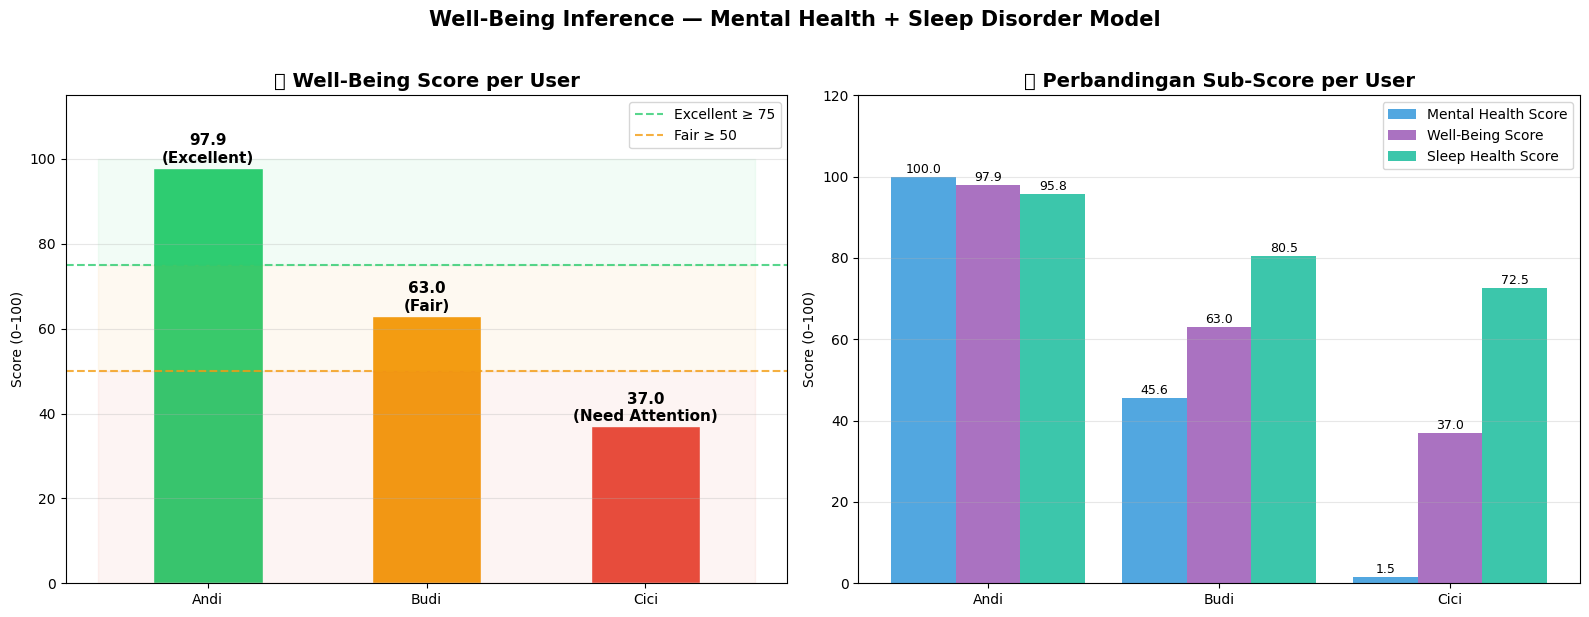

✅ Visualisasi tersimpan: wellbeing_inference.png


In [106]:
# ══════════════════════════════════════════════════════════════════════════════
#  Visualisasi Perbandingan Well-Being Score
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

users      = df_results['name'].tolist()
wb_scores  = df_results['well_being_score'].tolist()
m_scores   = df_results['mental_health_score'].tolist()
s_scores   = df_results['sleep_health_score'].tolist()
categories = df_results['category'].tolist()

# Warna per kategori
COLOR_MAP = {
    'Excellent'     : '#2ecc71',
    'Fair'          : '#f39c12',
    'Need Attention': '#e74c3c',
}
bar_colors = [COLOR_MAP[c] for c in categories]

# ── Plot 1: Well-Being Score ──────────────────────────────────────────────────
bars = axes[0].bar(users, wb_scores, color=bar_colors, edgecolor='white', width=0.5)
for bar, score, cat in zip(bars, wb_scores, categories):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        f'{score:.1f}\n({cat})',
        ha='center', fontsize=11, fontweight='bold'
    )

# Garis threshold
axes[0].axhline(75, color='#2ecc71', linestyle='--', linewidth=1.5, alpha=0.8, label='Excellent ≥ 75')
axes[0].axhline(50, color='#f39c12', linestyle='--', linewidth=1.5, alpha=0.8, label='Fair ≥ 50')
axes[0].fill_between([-0.5, 2.5], 75, 100, color='#2ecc71', alpha=0.06)
axes[0].fill_between([-0.5, 2.5], 50,  75, color='#f39c12', alpha=0.06)
axes[0].fill_between([-0.5, 2.5],  0,  50, color='#e74c3c', alpha=0.06)

axes[0].set_title('⭐ Well-Being Score per User', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score (0–100)')
axes[0].set_ylim(0, 115)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ── Plot 2: Sub-scores (grouped bar) ─────────────────────────────────────────
x      = np.arange(len(users))
width  = 0.28

b1 = axes[1].bar(x - width, m_scores, width, label='Mental Health Score', color='#3498db', alpha=0.85)
b2 = axes[1].bar(x,         wb_scores, width, label='Well-Being Score',   color='#9b59b6', alpha=0.85)
b3 = axes[1].bar(x + width, s_scores, width, label='Sleep Health Score',  color='#1abc9c', alpha=0.85)

for bars_group in [b1, b2, b3]:
    for bar in bars_group:
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{bar.get_height():.1f}',
            ha='center', fontsize=9
        )

axes[1].set_title('📊 Perbandingan Sub-Score per User', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(users)
axes[1].set_ylabel('Score (0–100)')
axes[1].set_ylim(0, 120)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Well-Being Inference — Mental Health + Sleep Disorder Model',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wellbeing_inference.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Visualisasi tersimpan: wellbeing_inference.png')

In [107]:
# ══════════════════════════════════════════════════════════════════════════════
#  Detail Probabilitas — Sleep Disorder per User
# ══════════════════════════════════════════════════════════════════════════════

print('\n📋 Detail Probabilitas Gangguan Tidur per User:')
print('─' * 70)

sleep_data = [
    ('Andi', andi_sleep),
    ('Budi', budi_sleep),
    ('Cici', cici_sleep),
]

sleep_df_rows = []
for name, raw in sleep_data:
    res = sleep_predictor.predict(raw)
    row = {'User': name, 'Prediksi': res['predicted_class'], 'Confidence (%)': res['confidence']}
    row.update({k: f"{v:.1f}%" for k, v in res['class_probabilities'].items()})
    sleep_df_rows.append(row)

df_sleep_detail = pd.DataFrame(sleep_df_rows)
print(df_sleep_detail.to_string(index=False))

# ── Summary tabel final ───────────────────────────────────────────────────────
print('\n' + '═'*70)
print('  ✅ RINGKASAN FINAL WELL-BEING INFERENCE')
print('═'*70)
for _, row in df_results.iterrows():
    print(
        f"  {row['emoji']}  {row['name']:5s} │ "
        f"WB Score: {row['well_being_score']:5.1f} │ "
        f"Mental: {row['mental_health_score']:5.1f} │ "
        f"Sleep: {row['sleep_health_score']:5.1f} │ "
        f"Kategori: {row['category']}"
    )
print('═'*70)


📋 Detail Probabilitas Gangguan Tidur per User:
──────────────────────────────────────────────────────────────────────
User Prediksi  Confidence (%)     No Insomnia Restless Leg Syndrome Narcolepsy Sleep Apnea
Andi       No           99.99 100.0%     0.0%                  0.0%       0.0%        0.0%
Budi       No          100.00 100.0%     0.0%                  0.0%       0.0%        0.0%
Cici       No           99.89  99.9%     0.0%                  0.0%       0.0%        0.1%

══════════════════════════════════════════════════════════════════════
  ✅ RINGKASAN FINAL WELL-BEING INFERENCE
══════════════════════════════════════════════════════════════════════
  🟢  Andi  │ WB Score:  97.9 │ Mental: 100.0 │ Sleep:  95.8 │ Kategori: Excellent
  🟡  Budi  │ WB Score:  63.0 │ Mental:  45.6 │ Sleep:  80.5 │ Kategori: Fair
  🔴  Cici  │ WB Score:  37.0 │ Mental:   1.5 │ Sleep:  72.5 │ Kategori: Need Attention
══════════════════════════════════════════════════════════════════════
